# Lab 2 — Anomaly Detection for Cybersecurity Logs

## Student

- Dror Sullam

## Scenario

This notebook simulates login events and uses Isolation Forest to detect anomalous authentication behavior.

## MITRE ATT&CK Mapping

- T1110 — Brute Force
- T1078 — Valid Accounts

The simulated anomalies represent suspicious login behavior such as many failed login attempts, unusual login hours, unknown devices, and rare countries.

In [1]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [2]:
np.random.seed(42)

n_normal = 970
n_anomalies = 30

users = ["alice", "bob", "charlie", "dana", "eve", "frank"]
normal_countries = ["Israel", "USA", "Germany"]
normal_devices = ["Mac", "Windows", "Linux"]

# Normal login events
normal_data = pd.DataFrame({
    "hour": np.random.normal(loc=13, scale=3, size=n_normal).clip(7, 22).round().astype(int),
    "failed_attempts": np.random.poisson(lam=0.4, size=n_normal),
    "session_duration_minutes": np.random.normal(loc=35, scale=12, size=n_normal).clip(5, 90).round().astype(int),
    "user": np.random.choice(users, size=n_normal),
    "country": np.random.choice(normal_countries, size=n_normal, p=[0.70, 0.20, 0.10]),
    "device": np.random.choice(normal_devices, size=n_normal, p=[0.45, 0.45, 0.10]),
    "label": "normal"
})

# Anomalous login events
anomaly_data = pd.DataFrame({
    "hour": np.random.choice([0, 1, 2, 3, 4, 5], size=n_anomalies),
    "failed_attempts": np.random.randint(8, 25, size=n_anomalies),
    "session_duration_minutes": np.random.randint(1, 8, size=n_anomalies),
    "user": np.random.choice(["admin", "root", "service_account"], size=n_anomalies),
    "country": np.random.choice(["Russia", "China", "Iran", "North Korea"], size=n_anomalies),
    "device": np.random.choice(["Unknown", "Headless", "OldBrowser"], size=n_anomalies),
    "label": "anomaly"
})

df = pd.concat([normal_data, anomaly_data], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,hour,failed_attempts,session_duration_minutes,user,country,device,label
0,15,0,32,eve,USA,Windows,normal
1,16,0,31,frank,Israel,Mac,normal
2,7,0,30,bob,Israel,Mac,normal
3,11,0,31,frank,Germany,Mac,normal
4,10,1,41,bob,USA,Windows,normal


In [3]:
print("Number of rows:", df.shape[0])
print("Number of features:", df.shape[1] - 1)

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass distribution (%):")
print(df["label"].value_counts(normalize=True) * 100)

df.describe(include="all")

Number of rows: 1000
Number of features: 6

Class distribution:
label
normal     970
anomaly     30
Name: count, dtype: int64

Class distribution (%):
label
normal     97.0
anomaly     3.0
Name: proportion, dtype: float64


,hour,failed_attempts,session_duration_minutes,user,country,device,label
count,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000
unique,NaN,NaN,NaN,9,7,6,2
top,NaN,NaN,NaN,dana,Israel,Mac,normal
freq,NaN,NaN,NaN,179,681,439,970
mean,12.773000,0.873000,34.150000,NaN,NaN,NaN,NaN
std,3.402506,2.934874,12.758302,NaN,NaN,NaN,NaN
min,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
25%,11.000000,0.000000,26.000000,NaN,NaN,NaN,NaN
50%,13.000000,0.000000,34.000000,NaN,NaN,NaN,NaN
75%,15.000000,1.000000,43.000000,NaN,NaN,NaN,NaN


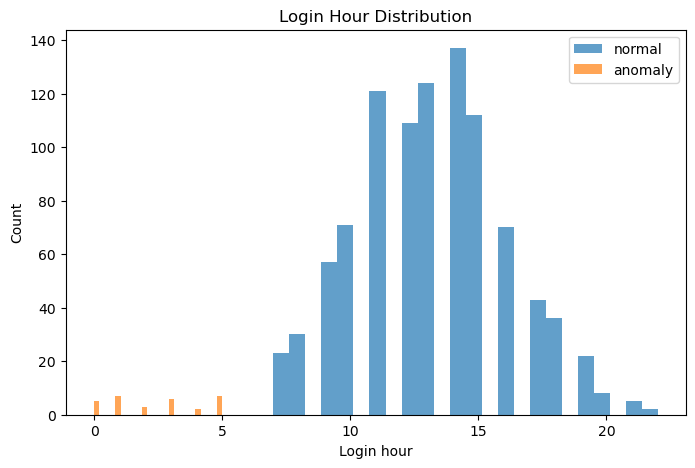

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df[df["label"] == "normal"]["hour"], bins=24, alpha=0.7, label="normal")
plt.hist(df[df["label"] == "anomaly"]["hour"], bins=24, alpha=0.7, label="anomaly")
plt.xlabel("Login hour")
plt.ylabel("Count")
plt.title("Login Hour Distribution")
plt.legend()
plt.show()

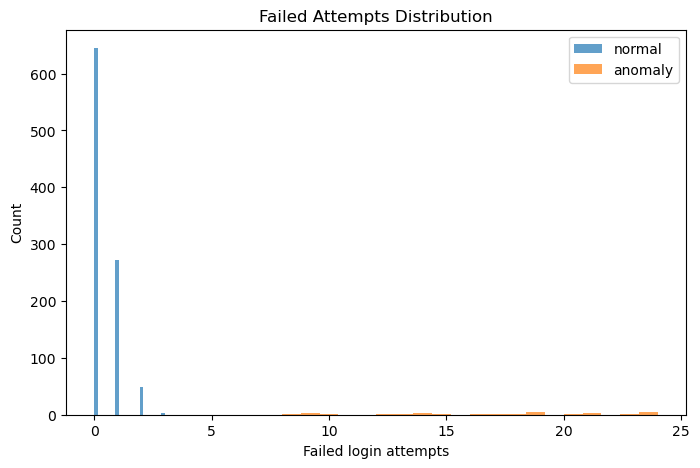

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df[df["label"] == "normal"]["failed_attempts"], bins=20, alpha=0.7, label="normal")
plt.hist(df[df["label"] == "anomaly"]["failed_attempts"], bins=20, alpha=0.7, label="anomaly")
plt.xlabel("Failed login attempts")
plt.ylabel("Count")
plt.title("Failed Attempts Distribution")
plt.legend()
plt.show()

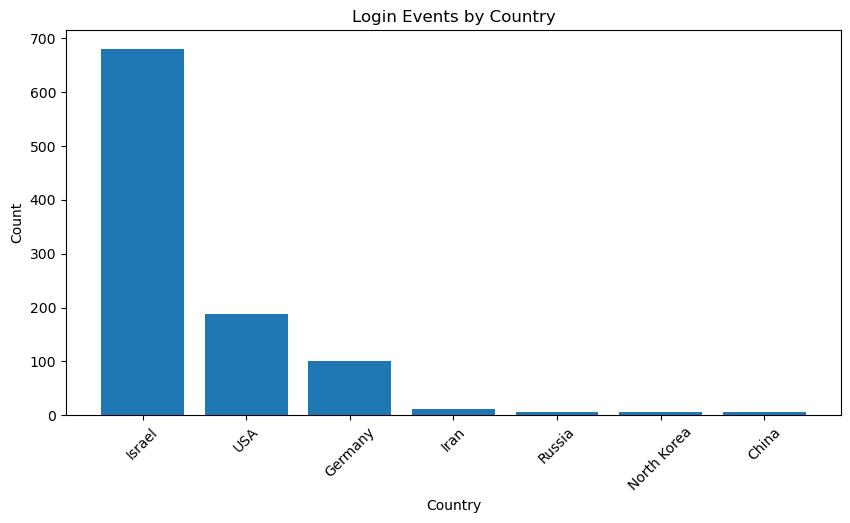

In [6]:
country_counts = df["country"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(country_counts.index, country_counts.values)
plt.xlabel("Country")
plt.ylabel("Count")
plt.title("Login Events by Country")
plt.xticks(rotation=45)
plt.show()

## EDA Summary

The normal login events mostly happen during working hours and usually contain very few failed attempts. Most normal users log in from common countries such as Israel, USA, and Germany, using known devices such as Mac, Windows, or Linux.

The anomalous events are intentionally different: they occur at unusual night hours, contain many failed login attempts, use privileged account names such as admin or root, and come from rare countries or unknown devices.

Therefore, we expect an anomaly detection model to find these events as isolated points compared to the normal login behavior.

In [7]:
feature_columns = ["hour", "failed_attempts", "session_duration_minutes", "user", "country", "device"]

X = df[feature_columns]
y_true = df["label"]

numeric_features = ["hour", "failed_attempts", "session_duration_minutes"]
categorical_features = ["user", "country", "device"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Processed shape:", X_processed.shape)

Original shape: (1000, 6)
Processed shape: (1000, 25)


In [8]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

model.fit(X_processed)

df["anomaly_score"] = model.decision_function(X_processed)
df["prediction_raw"] = model.predict(X_processed)

# IsolationForest returns:
#  1  = normal
# -1  = anomaly
df["predicted_label"] = np.where(df["prediction_raw"] == -1, "anomaly", "normal")

df[
    [
        "hour",
        "failed_attempts",
        "session_duration_minutes",
        "user",
        "country",
        "device",
        "label",
        "anomaly_score",
        "predicted_label"
    ]
].head(10)

,hour,failed_attempts,session_duration_minutes,user,country,device,label,anomaly_score,predicted_label
0,15,0,32,eve,USA,Windows,normal,0.083639,normal
1,16,0,31,frank,Israel,Mac,normal,0.148355,normal
2,7,0,30,bob,Israel,Mac,normal,0.120565,normal
3,11,0,31,frank,Germany,Mac,normal,0.074832,normal
4,10,1,41,bob,USA,Windows,normal,0.076392,normal
5,16,0,47,bob,Germany,Mac,normal,0.065432,normal
6,10,0,23,charlie,Israel,Linux,normal,0.087939,normal
7,10,1,36,bob,Israel,Mac,normal,0.127425,normal
8,15,1,21,alice,Israel,Windows,normal,0.124621,normal
9,11,1,8,charlie,Israel,Mac,normal,0.105875,normal


In [9]:
print("True labels:")
print(df["label"].value_counts())

print("\nPredicted labels:")
print(df["predicted_label"].value_counts())

print("\nConfusion matrix:")
cm = confusion_matrix(y_true, df["predicted_label"], labels=["normal", "anomaly"])
print(cm)

accuracy = accuracy_score(y_true, df["predicted_label"])
precision = precision_score(y_true, df["predicted_label"], pos_label="anomaly")
recall = recall_score(y_true, df["predicted_label"], pos_label="anomaly")

print("\nAccuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))

True labels:
label
normal     970
anomaly     30
Name: count, dtype: int64

Predicted labels:
predicted_label
normal     970
anomaly     30
Name: count, dtype: int64

Confusion matrix:
[[970   0]
 [  0  30]]

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


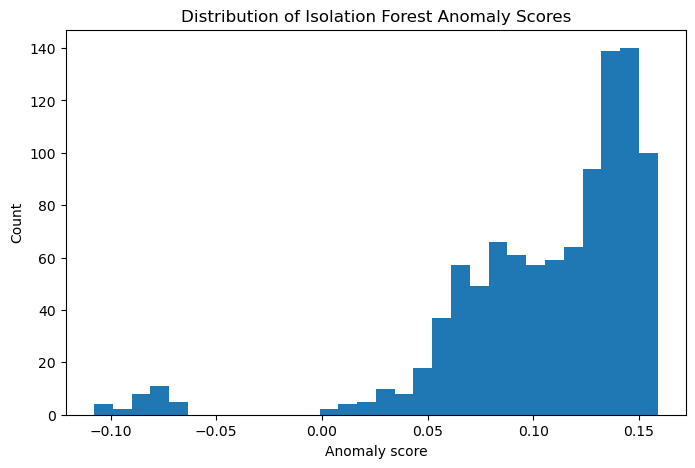

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["anomaly_score"], bins=30)
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.show()

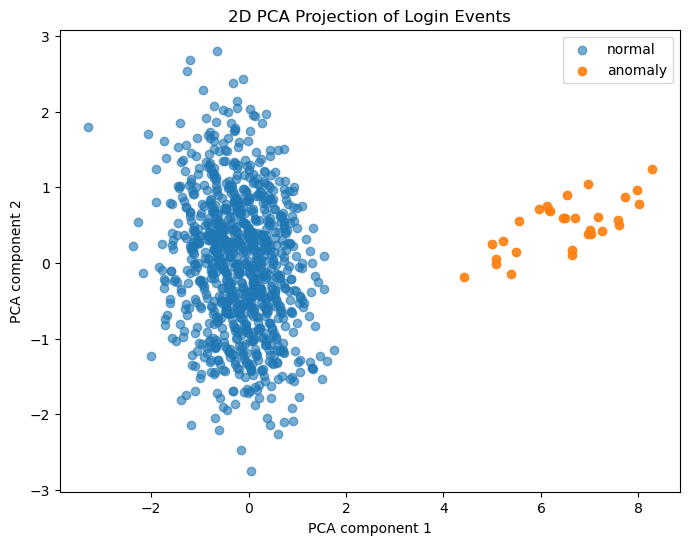

In [11]:
pca = PCA(n_components=2, random_state=42)

# X_processed may be sparse because of OneHotEncoder, so convert to dense if needed.
X_dense = X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed

X_2d = pca.fit_transform(X_dense)

df["pca_1"] = X_2d[:, 0]
df["pca_2"] = X_2d[:, 1]

normal_points = df[df["predicted_label"] == "normal"]
anomaly_points = df[df["predicted_label"] == "anomaly"]

plt.figure(figsize=(8, 6))
plt.scatter(normal_points["pca_1"], normal_points["pca_2"], label="normal", alpha=0.6)
plt.scatter(anomaly_points["pca_1"], anomaly_points["pca_2"], label="anomaly", alpha=0.9)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("2D PCA Projection of Login Events")
plt.legend()
plt.show()

## 2D Projection Summary

The PCA visualization shows most normal login events grouped together in a dense region. The predicted anomalies appear farther from the main cluster or in sparse areas of the plot.

This fits the intuition behind Isolation Forest: unusual events are easier to isolate because their feature combinations are rare compared to normal behavior.

## Conclusion

In this lab, we created a synthetic cybersecurity login dataset and used Isolation Forest to detect anomalous authentication behavior. The dataset included time-based, numeric, and categorical features, and the anomalies represented a small minority of the data.

The model achieved precision and recall of 1.0 on this synthetic dataset, meaning it correctly identified all anomalous login events without false positives. This strong result happened because the anomalies were intentionally designed to be clearly different from normal behavior: unusual login hours, many failed attempts, privileged account names, rare countries, unknown devices, and very short session durations.

This demonstrates how unsupervised anomaly detection can help SOC analysts find suspicious behavior even when attack labels are limited or unavailable. The main limitation is that the dataset was synthetic and intentionally separable. In a real environment, user behavior is noisier, false positives are common, attackers may behave more subtly, and thresholds require careful tuning by human analysts.